In [1]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import time
from torch.utils.tensorboard import SummaryWriter

In [2]:
DATA_DIR = "cow"
NUM_CLASSES = 5
BATCH_SIZE = 32
EPOCHS = 12
VAL_SPLIT = 0.2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
writer = SummaryWriter("runs/cow_efficientnet")

In [3]:
train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [4]:
full_dataset = datasets.ImageFolder(DATA_DIR)

train_size = int((1-VAL_SPLIT) * len(full_dataset))
val_size = len(full_dataset) - train_size

train_ds, val_ds = random_split(full_dataset, [train_size, val_size])

# assign transforms
train_ds.dataset.transform = train_tf
val_ds.dataset.transform = val_tf

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print("Classes:", full_dataset.classes)
print("Train samples:", train_size)
print("Val samples:", val_size)

Classes: ['Ayrshire cattle', 'Brown Swiss cattle', 'Holstein Friesian cattle', 'Jersey cattle', 'Red Dane cattle']
Train samples: 966
Val samples: 242


In [5]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, NUM_CLASSES)
)

model = model.to(device)

# -----------------------
# Training setup
# -----------------------

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)

In [6]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):

    t0 = time.time()

    # ----- train -----
    model.train()
    running_loss = 0
    preds_all = []
    labels_all = []

    for imgs, labels in train_loader:

        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

        preds = outputs.argmax(1)

        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    train_loss = running_loss / train_size
    train_acc = accuracy_score(labels_all, preds_all)

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ----- validation -----
    model.eval()

    running_loss = 0
    preds_all = []
    labels_all = []

    with torch.no_grad():

        for imgs, labels in val_loader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)

            preds = outputs.argmax(1)

            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    val_loss = running_loss / val_size
    val_acc = accuracy_score(labels_all, preds_all)

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Accuracy/train", train_acc, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)
    writer.add_scalar("LR", scheduler.get_last_lr()[0], epoch)

    scheduler.step()

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"time={time.time()-t0:.1f}s"
    )

writer.close()

Epoch 1/12 | train_loss=1.4161 train_acc=0.4648 | val_loss=1.1176 val_acc=0.7479 | time=22.9s
Epoch 2/12 | train_loss=0.8791 train_acc=0.8116 | val_loss=0.7099 val_acc=0.8099 | time=20.5s
Epoch 3/12 | train_loss=0.5334 train_acc=0.8623 | val_loss=0.4943 val_acc=0.8719 | time=20.5s
Epoch 4/12 | train_loss=0.3481 train_acc=0.9058 | val_loss=0.3714 val_acc=0.8967 | time=20.6s
Epoch 5/12 | train_loss=0.2159 train_acc=0.9555 | val_loss=0.2871 val_acc=0.9132 | time=20.4s
Epoch 6/12 | train_loss=0.1622 train_acc=0.9669 | val_loss=0.2883 val_acc=0.9091 | time=20.2s
Epoch 7/12 | train_loss=0.1719 train_acc=0.9607 | val_loss=0.2763 val_acc=0.9256 | time=20.6s
Epoch 8/12 | train_loss=0.1452 train_acc=0.9700 | val_loss=0.2730 val_acc=0.9174 | time=20.2s
Epoch 9/12 | train_loss=0.1338 train_acc=0.9772 | val_loss=0.2710 val_acc=0.9091 | time=20.5s
Epoch 10/12 | train_loss=0.1396 train_acc=0.9648 | val_loss=0.2646 val_acc=0.9174 | time=20.5s
Epoch 11/12 | train_loss=0.1340 train_acc=0.9741 | val_loss

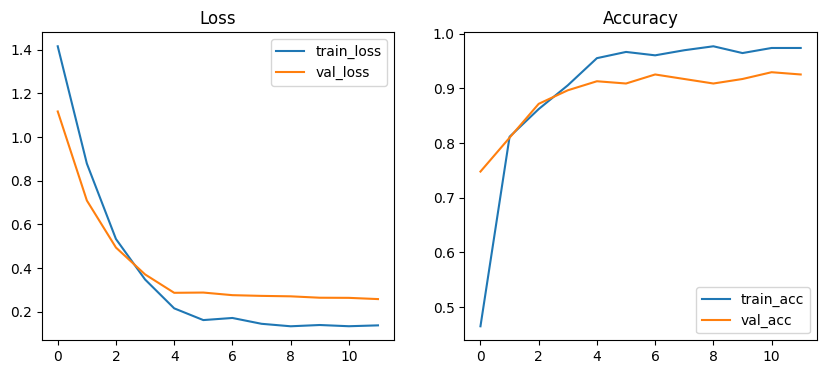

In [7]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses,label="train_loss")
plt.plot(val_losses,label="val_loss")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs,label="train_acc")
plt.plot(val_accs,label="val_acc")
plt.title("Accuracy")
plt.legend()

plt.show()